# Twenty-five neighborhoods

`Neighborhood` is a name, not a number. There are 25 names in the training file. The median price runs from Meadow Village to Northridge Heights.

| Code | Place | Houses | Median price |
|---|---|---:|---:|
| `MeadowV` | Meadow Village | 17 | 88000 |
| `Edwards` | Edwards | 100 | 121750 |
| `NAmes` | North Ames | 225 | 140000 |
| `CollgCr` | College Creek | 150 | 197200 |
| `NoRidge` | Northridge | 41 | 301500 |
| `NridgHt` | Northridge Heights | 77 | 315000 |

North Ames alone is 225 of the 1460 sales. College Creek, where house 1 stands, has median 197200, and house 1 sold for 208500. Edwards has a middling median and, as a later lesson shows, two enormous partial sales that a mean would chase and a median does not.

A model that replaces each name by the mean price of that name, computed on the same rows it then scores, memorizes the neighborhood. The holdout lesson refits any such table on the houses it is allowed to see.


In [2]:
# Locate the contest tables beside this notebook, or under the course root.
from pathlib import Path
import csv

def manifest_path(name):
    here = Path.cwd()
    for folder in [here, *here.parents]:
        nested = folder / "15-House Prices" / "data" / name
        direct = folder / "data" / name
        if nested.exists():
            return nested
        if direct.exists() and (folder / "data" / "data_description.txt").exists():
            return direct
    raise FileNotFoundError(name)

def read_manifest(name):
    with manifest_path(name).open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

train = read_manifest("train.csv")
test = read_manifest("test.csv")
submission = read_manifest("sample_submission.csv")
print(len(train), len(test), len(submission))
print(train[0]["Id"], train[0]["SalePrice"])


1460 1459 1459
1 208500


In [3]:
# Median price by neighborhood, for the six places named above.
from fractions import Fraction
from collections import defaultdict
groups = defaultdict(list)
for row in train:
    groups[row["Neighborhood"]].append(int(row["SalePrice"]))
assert len(groups) == 25

def median(values):
    ordered = sorted(values)
    count = len(ordered)
    if count % 2 == 1:
        return Fraction(ordered[count // 2])
    return Fraction(ordered[count // 2 - 1] + ordered[count // 2], 2)

expected = {
    "MeadowV": (17, 88000),
    "Edwards": (100, 121750),
    "NAmes": (225, 140000),
    "CollgCr": (150, 197200),
    "NoRidge": (41, 301500),
    "NridgHt": (77, 315000),
}
for name, (count, mid) in expected.items():
    print(name, len(groups[name]), median(groups[name]))
    assert len(groups[name]) == count
    assert median(groups[name]) == Fraction(mid)


MeadowV 17 88000
Edwards 100 121750
NAmes 225 140000
CollgCr 150 197200
NoRidge 41 301500
NridgHt 77 315000


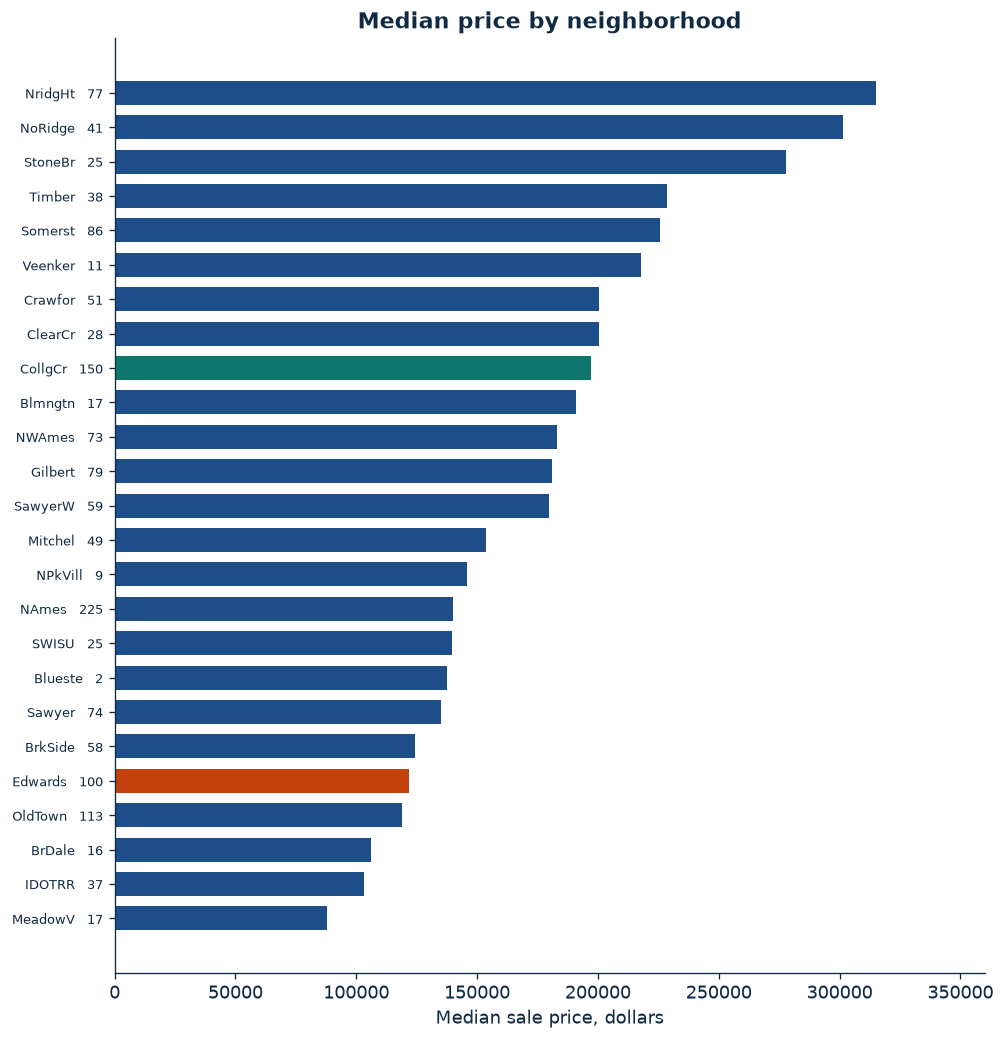

In [4]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#102a43",
    "axes.labelcolor": "#102a43",
    "xtick.color": "#102a43",
    "ytick.color": "#102a43",
    "text.color": "#102a43",
})
# All 25 medians, cheapest at the bottom, axis starting at zero.
from fractions import Fraction
from collections import defaultdict
groups = defaultdict(list)
for row in train:
    groups[row["Neighborhood"]].append(int(row["SalePrice"]))

def median(values):
    ordered = sorted(values)
    count = len(ordered)
    if count % 2 == 1:
        return Fraction(ordered[count // 2])
    return Fraction(ordered[count // 2 - 1] + ordered[count // 2], 2)

ranked = sorted(
    ((float(median(values)), len(values), name) for name, values in groups.items()),
    key=lambda item: item[0],
)
figure, axis = plt.subplots(figsize=(8.6, 8.8))
positions = list(range(len(ranked)))
colors = ["#1d4e89"] * len(ranked)
for index, (_, _, name) in enumerate(ranked):
    if name == "CollgCr":
        colors[index] = "#0f766e"
    if name in ("Edwards", "MeadowV", "NridgHt"):
        colors[index] = "#c2410c" if name == "Edwards" else colors[index]
axis.barh(
    positions,
    [mid for mid, _, _ in ranked],
    color=colors,
    height=0.7,
)
axis.set_yticks(
    positions,
    [f"{name}   {count}" for _, count, name in ranked],
    fontsize=8,
)
axis.set_xlim(0, 360000)
axis.set_xlabel("Median sale price, dollars")
axis.set_title("Median price by neighborhood")
figure.tight_layout()


## Pitfall

College Creek is the green bar. Edwards is clay. Edwards is not a cheap neighborhood in the sense Meadow Village is: its median is 121750, and its mean is dragged by two partial sales of huge houses. A neighborhood label is a location, and it still contains more than one kind of sale.

## Summary

25 names. Meadow Village's median is 88000 on 17 houses. Northridge Heights' median is 315000 on 77 houses. North Ames is the largest group, 225 houses, median 140000.
